<a href="https://colab.research.google.com/github/rvfalves/DIO_IA-Bootcamp/blob/bootcamp-projects/Yolo_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

import numpy as np

import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow

In [ ]:
!git clone https://github.com/pjreddie/darknet
%cd darknet
#!sed -i 's/OPENCV=0/OPENCV=1/' Makefile
#!sed -i 's/GPU=0/GPU=1/' Makefile
#!sed -i 's/CUDNN=0/CUDNN=1/' Makefile
!make

Cloning into 'darknet'...
remote: Enumerating objects: 5955, done.
remote: Total 5955 (delta 0), reused 0 (delta 0), pack-reused 5955 (from 1)
Receiving objects: 100% (5955/5955), 6.37 MiB | 19.60 MiB/s, done.
Resolving deltas: 100% (3931/3931), done.
/content/darknet
mkdir -p obj
mkdir -p backup
mkdir -p results
gcc -Iinclude/ -Isrc/ -Wall -Wno-unused-result -Wno-unknown-pragmas -Wfatal-errors -fPIC -Ofast -c ./src/gemm.c -o obj/gemm.o
gcc -Iinclude/ -Isrc/ -Wall -Wno-unused-result -Wno-unknown-pragmas -Wfatal-errors -fPIC -Ofast -c ./src/utils.c -o obj/utils.o
gcc -Iinclude/ -Isrc/ -Wall -Wno-unused-result -Wno-unknown-pragmas -Wfatal-errors -fPIC -Ofast -c ./src/cuda.c -o obj/cuda.o
gcc -Iinclude/ -Isrc/ -Wall -Wno-unused-result -Wno-unknown-pragmas -Wfatal-errors -fPIC -Ofast -c ./src/deconvolutional_layer.c -o obj/deconvolutional_layer.o
gcc -Iinclude/ -Isrc/ -Wall -Wno-unused-result -Wno-unknown-pragmas -Wfatal-errors -fPIC -Ofast -c ./src/convolutional_layer.c -o obj/convolution

In [ ]:
!wget https://pjreddie.com/media/files/yolov3.weights

--2025-02-07 12:55:54--  https://pjreddie.com/media/files/yolov3.weights
Resolving pjreddie.com (pjreddie.com)... 162.0.215.52
Connecting to pjreddie.com (pjreddie.com)|162.0.215.52|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 248007048 (237M) [application/octet-stream]
Saving to: ‘yolov3.weights’

yolov3.weights      100%[===================>] 236.52M  27.8MB/s    in 9.0s    

2025-02-07 12:56:03 (26.2 MB/s) - ‘yolov3.weights’ saved [248007048/248007048]



In [ ]:
!./darknet detect cfg/yolov3.cfg yolov3.weights data/dog.jpg #-gpus 0,1,2,3

layer     filters    size              input                output
    0 conv     32  3 x 3 / 1   608 x 608 x   3   ->   608 x 608 x  32  0.639 BFLOPs
    1 conv     64  3 x 3 / 2   608 x 608 x  32   ->   304 x 304 x  64  3.407 BFLOPs
    2 conv     32  1 x 1 / 1   304 x 304 x  64   ->   304 x 304 x  32  0.379 BFLOPs
    3 conv     64  3 x 3 / 1   304 x 304 x  32   ->   304 x 304 x  64  3.407 BFLOPs
    4 res    1                 304 x 304 x  64   ->   304 x 304 x  64
    5 conv    128  3 x 3 / 2   304 x 304 x  64   ->   152 x 152 x 128  3.407 BFLOPs
    6 conv     64  1 x 1 / 1   152 x 152 x 128   ->   152 x 152 x  64  0.379 BFLOPs
    7 conv    128  3 x 3 / 1   152 x 152 x  64   ->   152 x 152 x 128  3.407 BFLOPs
    8 res    5                 152 x 152 x 128   ->   152 x 152 x 128
    9 conv     64  1 x 1 / 1   152 x 152 x 128   ->   152 x 152 x  64  0.379 BFLOPs
   10 conv    128  3 x 3 / 1   152 x 152 x  64   ->   152 x 152 x 128  3.407 BFLOPs
   11 res    8                 152 x 

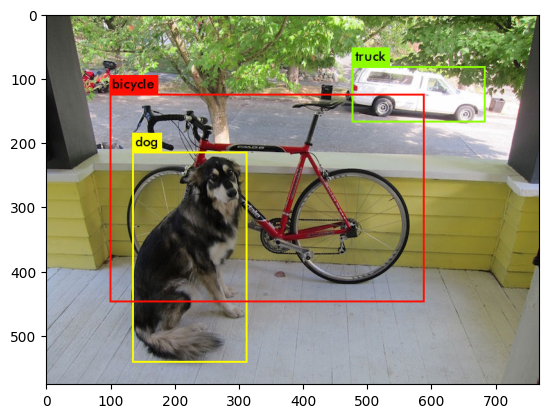

In [ ]:
figure = plt.imread('/content/darknet/predictions.jpg')
plt.imshow(figure)

In [ ]:
!./darknet detect cfg/yolov3.cfg yolov3.weights data/horses.jpg #-gpus 0,1,2,3

layer     filters    size              input                output
    0 conv     32  3 x 3 / 1   608 x 608 x   3   ->   608 x 608 x  32  0.639 BFLOPs
    1 conv     64  3 x 3 / 2   608 x 608 x  32   ->   304 x 304 x  64  3.407 BFLOPs
    2 conv     32  1 x 1 / 1   304 x 304 x  64   ->   304 x 304 x  32  0.379 BFLOPs
    3 conv     64  3 x 3 / 1   304 x 304 x  32   ->   304 x 304 x  64  3.407 BFLOPs
    4 res    1                 304 x 304 x  64   ->   304 x 304 x  64
    5 conv    128  3 x 3 / 2   304 x 304 x  64   ->   152 x 152 x 128  3.407 BFLOPs
    6 conv     64  1 x 1 / 1   152 x 152 x 128   ->   152 x 152 x  64  0.379 BFLOPs
    7 conv    128  3 x 3 / 1   152 x 152 x  64   ->   152 x 152 x 128  3.407 BFLOPs
    8 res    5                 152 x 152 x 128   ->   152 x 152 x 128
    9 conv     64  1 x 1 / 1   152 x 152 x 128   ->   152 x 152 x  64  0.379 BFLOPs
   10 conv    128  3 x 3 / 1   152 x 152 x  64   ->   152 x 152 x 128  3.407 BFLOPs
   11 res    8                 152 x 

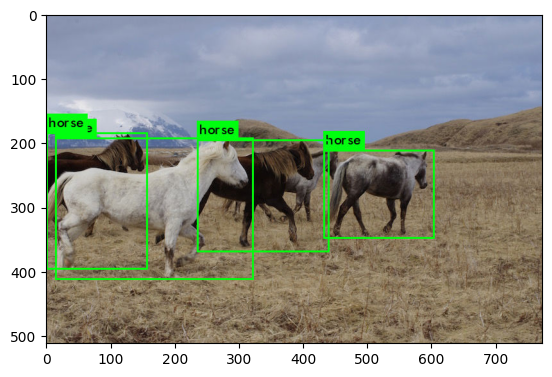

In [ ]:
figure = plt.imread('/content/darknet/predictions.jpg')
plt.imshow(figure)

In [ ]:
!mkdir data_coco

In [ ]:
!cp scripts/get_coco_dataset.sh data_coco
%cd data_coco

/content/darknet/data_coco


**Alterar arquivo /content/darknet/data_coco/get_coco_dataset.sh**


In [ ]:
!bash get_coco_dataset.sh

Streaming output truncated to the last 5000 lines.
labels/train2014/COCO_train2014_000000078650.txt
labels/train2014/COCO_train2014_000000390914.txt
labels/train2014/COCO_train2014_000000001144.txt
labels/train2014/COCO_train2014_000000281959.txt
labels/train2014/COCO_train2014_000000175527.txt
labels/train2014/COCO_train2014_000000347866.txt
labels/train2014/COCO_train2014_000000287666.txt
labels/train2014/COCO_train2014_000000472344.txt
labels/train2014/COCO_train2014_000000444226.txt
labels/train2014/COCO_train2014_000000116911.txt
labels/train2014/COCO_train2014_000000491611.txt
labels/train2014/COCO_train2014_000000244461.txt
labels/train2014/COCO_train2014_000000068914.txt
labels/train2014/COCO_train2014_000000270906.txt
labels/train2014/COCO_train2014_000000450749.txt
labels/train2014/COCO_train2014_000000201042.txt
labels/train2014/COCO_train2014_000000228992.txt
labels/train2014/COCO_train2014_000000240414.txt
labels/train2014/COCO_train2014_000000542548.txt
labels/train2014/C

In [ ]:
%cd ..

/content/darknet


In [ ]:
!wget https://pjreddie.com/media/files/darknet53.conv.74

--2025-02-07 13:15:58--  https://pjreddie.com/media/files/darknet53.conv.74
Resolving pjreddie.com (pjreddie.com)... 162.0.215.52
Connecting to pjreddie.com (pjreddie.com)|162.0.215.52|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 162482580 (155M) [application/octet-stream]
Saving to: ‘darknet53.conv.74’

darknet53.conv.74   100%[===================>] 154.96M  34.5MB/s    in 4.7s    

2025-02-07 13:16:03 (33.1 MB/s) - ‘darknet53.conv.74’ saved [162482580/162482580]



**Alterar arquivo cfg/coco.data e cfg/yolov3.cfg**

In [ ]:
!./darknet detector train cfg/coco.data cfg/yolov3.cfg darknet53.conv.74 #-gpus 0,1,2,3
#!./darknet detector train cfg/coco.data cfg/yolov3.cfg yolov3.weights

yolov3
layer     filters    size              input                output
    0 conv     32  3 x 3 / 1   608 x 608 x   3   ->   608 x 608 x  32  0.639 BFLOPs
    1 conv     64  3 x 3 / 2   608 x 608 x  32   ->   304 x 304 x  64  3.407 BFLOPs
    2 conv     32  1 x 1 / 1   304 x 304 x  64   ->   304 x 304 x  32  0.379 BFLOPs
    3 conv     64  3 x 3 / 1   304 x 304 x  32   ->   304 x 304 x  64  3.407 BFLOPs
    4 res    1                 304 x 304 x  64   ->   304 x 304 x  64
    5 conv    128  3 x 3 / 2   304 x 304 x  64   ->   152 x 152 x 128  3.407 BFLOPs
    6 conv     64  1 x 1 / 1   152 x 152 x 128   ->   152 x 152 x  64  0.379 BFLOPs
    7 conv    128  3 x 3 / 1   152 x 152 x  64   ->   152 x 152 x 128  3.407 BFLOPs
    8 res    5                 152 x 152 x 128   ->   152 x 152 x 128
    9 conv     64  1 x 1 / 1   152 x 152 x 128   ->   152 x 152 x  64  0.379 BFLOPs
   10 conv    128  3 x 3 / 1   152 x 152 x  64   ->   152 x 152 x 128  3.407 BFLOPs
   11 res    8                

In [ ]:
!ls

In [ ]:
!./darknet detector train cfg/coco.data cfg/yolov3.cfg backup/yolov3.backup

/bin/bash: line 1: ./darknet: No such file or directory
